In [1]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'SEA-AD_Microglia-and-Immune_multi-regional_final-nuclei_AAIC-pre-release.2025-07-24.h5ad',
 'adata_small_1000.h5ad',
 'marker_genes.csv',
 'top_marker_genes.csv']

In [7]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.0 MB/s eta 0:00:00


In [9]:
!pip install scanpy -q

In [1]:
import scanpy as sc

adata = sc.read_h5ad(
    '/content/drive/MyDrive/SEA-AD_Microglia-and-Immune_multi-regional_final-nuclei_AAIC-pre-release.2025-07-24.h5ad',
    backed='r'
)

adata_small = adata[:1000, :].to_memory()

In [2]:
adata_small

AnnData object with n_obs × n_vars = 1000 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in month

In [3]:
adata_small.write('/content/drive/MyDrive/adata_small_1000.h5ad')

/usr/local/lib/python3.12/dist-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [4]:
print(adata_small.shape)
print(adata_small.obs.columns)

(1000, 36601)
Index(['sample_id', 'Neurotypical reference', 'Donor ID', 'Organism',
       'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)',
       'Race (choice=Black/ African American)',
       ...
       'Number of reads', 'Number of UMIs', 'Genes detected', 'Doublet score',
       'Fraction mitochondrial UMIs', 'Severely Affected Donor',
       'numeric_facs_population_plan', 'Class', 'Subclass', 'Supertype'],
      dtype='object', length=130)


In [5]:
#load the saved smaller SEA-AD dataset and inspect it carefully
import scanpy as sc
import pandas as pd

adata = sc.read_h5ad('/content/drive/MyDrive/adata_small_1000.h5ad')

print(adata)
print("\nShape:", adata.shape)
print("\nFirst 20 metadata columns:")
print(list(adata.obs.columns)[:20])

AnnData object with n_obs × n_vars = 1000 × 36601
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in month

In [6]:
print(adata.obs['Class'].value_counts())
print("\nSubclass distribution:")
print(adata.obs['Subclass'].value_counts())
print("\nSupertype distribution:")
print(adata.obs['Supertype'].value_counts())

Class
Non-neuronal and Non-neural    1000
Name: count, dtype: int64

Subclass distribution:
Subclass
Microglia-PVM    1000
Name: count, dtype: int64

Supertype distribution:
Supertype
Micro-PVM_2            730
Micro-PVM_2_3-SEAAD    150
Micro-PVM_3-SEAAD       95
Micro-PVM_1             17
Lymphocyte               6
Micro-PVM_2_1-SEAAD      1
Micro-PVM_4-SEAAD        1
Name: count, dtype: int64


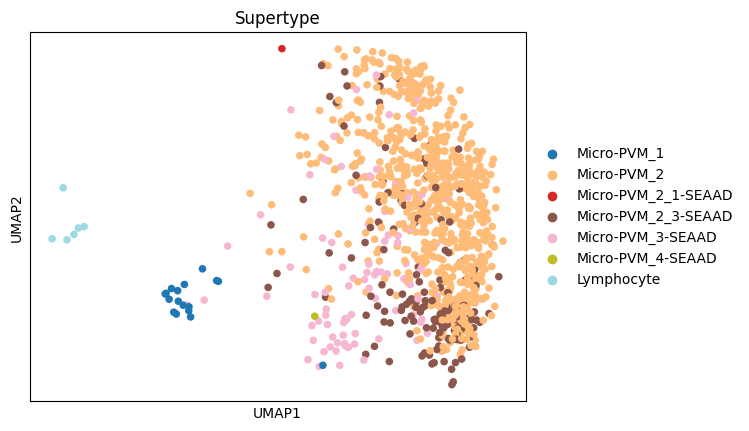

In [7]:
sc.pl.umap(adata, color='Supertype', palette='tab20')

In [8]:
# remove very small groups (less than 3 cells)
counts = adata.obs['Supertype'].value_counts()
valid_groups = counts[counts >= 3].index

adata_markers = adata[adata.obs['Supertype'].isin(valid_groups)].copy()

print(adata_markers.obs['Supertype'].value_counts())

Supertype
Micro-PVM_2            730
Micro-PVM_2_3-SEAAD    150
Micro-PVM_3-SEAAD       95
Micro-PVM_1             17
Lymphocyte               6
Name: count, dtype: int64


In [9]:
sc.tl.rank_genes_groups(adata_markers, groupby='Supertype', method='wilcoxon')

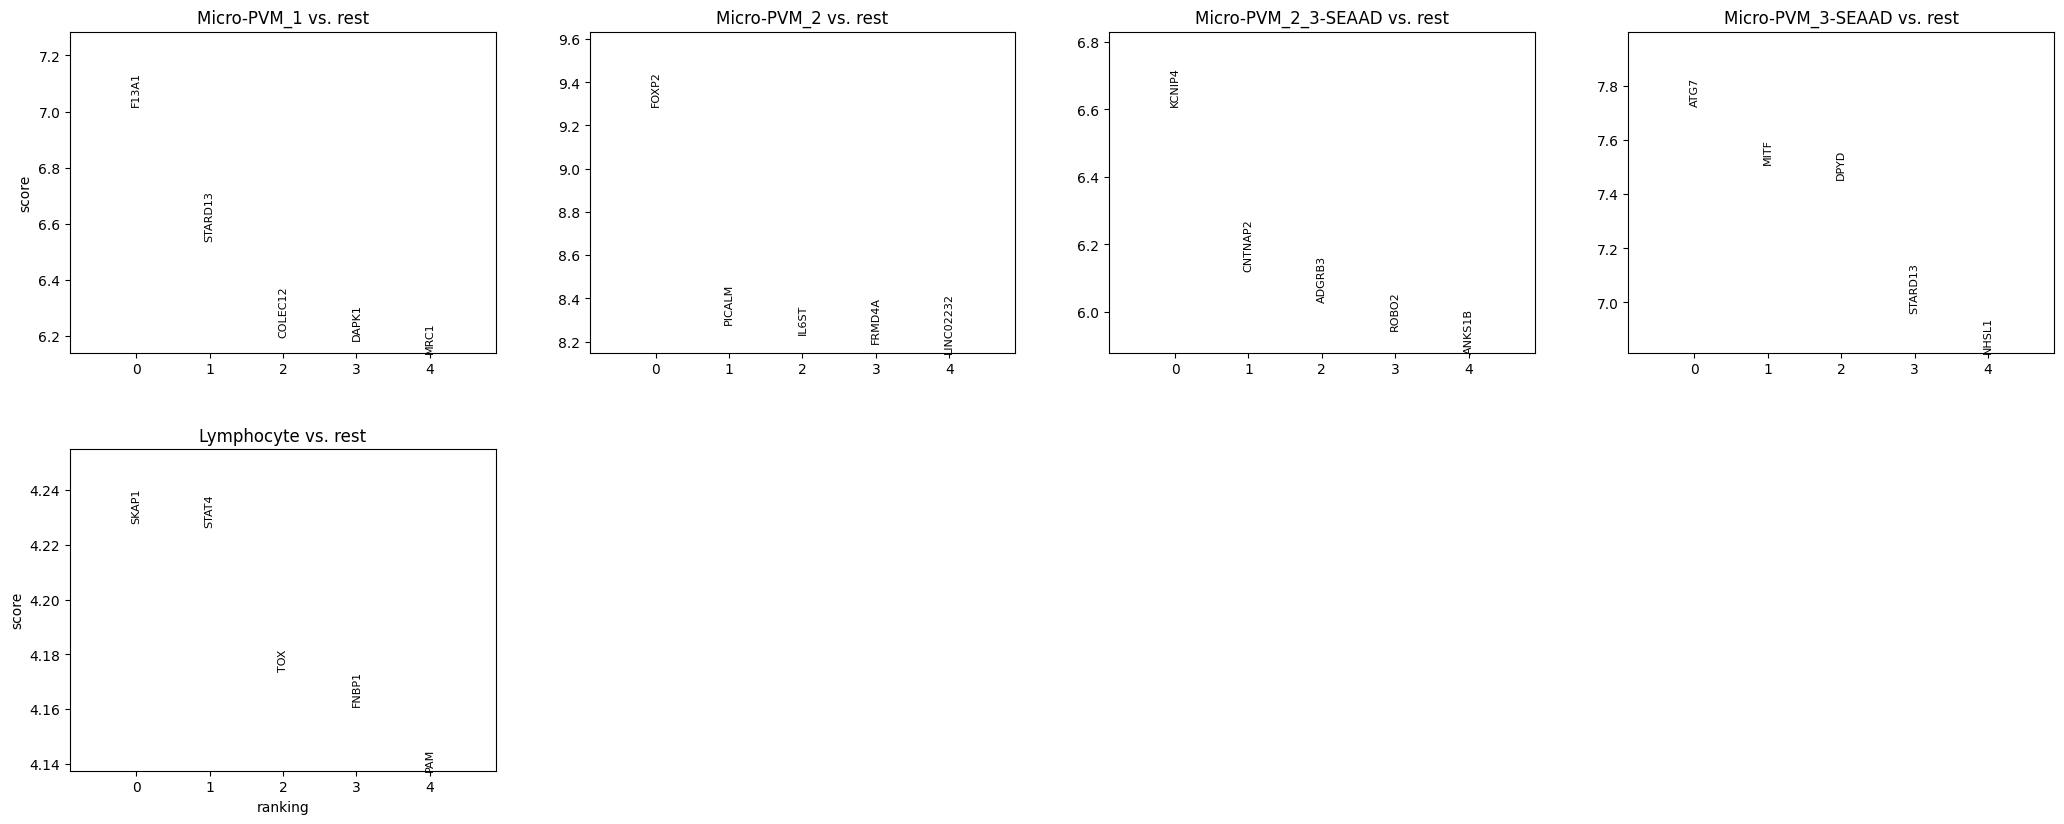

In [10]:
sc.pl.rank_genes_groups(adata_markers, n_genes=5, sharey=False)

In [11]:
markers = sc.get.rank_genes_groups_df(adata_markers, group=None)
markers.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Micro-PVM_1,F13A1,7.020785,9.623757,2.206247e-12,8.075085e-08
1,Micro-PVM_1,STARD13,6.537881,4.978561,6.239660e-11,4.567556e-07
2,Micro-PVM_1,COLEC12,6.195859,9.514892,5.796804e-10,2.281651e-06
3,Micro-PVM_1,DAPK1,6.184402,5.751043,6.233848e-10,2.281651e-06
4,Micro-PVM_1,MRC1,6.139421,5.321693,8.282277e-10,2.472873e-06
5,Micro-PVM_1,IQGAP2,6.072799,5.382227,1.256998e-09,3.286242e-06
6,Micro-PVM_1,MAN1A1,6.024424,4.143086,1.697133e-09,4.016927e-06
7,Micro-PVM_1,RBPJ,5.903061,3.625081,3.568183e-09,6.348316e-06
8,Micro-PVM_1,MYO5A,5.887784,3.062978,3.914069e-09,6.511765e-06
9,Micro-PVM_1,RGL1,5.765997,4.937286,8.117622e-09,1.241090e-05


In [12]:
markers.to_csv('/content/drive/MyDrive/marker_genes.csv', index=False)

In [13]:
#top 5 genes per supertype
top_markers = markers.groupby('group').head(5)

top_markers

/tmp/ipykernel_6671/2433460784.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_markers = markers.groupby('group').head(5)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Micro-PVM_1,F13A1,7.020785,9.623757,2.206247e-12,8.075085e-08
1,Micro-PVM_1,STARD13,6.537881,4.978561,6.239660e-11,4.567556e-07
2,Micro-PVM_1,COLEC12,6.195859,9.514892,5.796804e-10,2.281651e-06
3,Micro-PVM_1,DAPK1,6.184402,5.751043,6.233848e-10,2.281651e-06
4,Micro-PVM_1,MRC1,6.139421,5.321693,8.282277e-10,2.472873e-06
36601,Micro-PVM_2,FOXP2,9.291529,1.953512,1.520885e-20,5.566591e-16
36602,Micro-PVM_2,PICALM,8.278698,0.874335,1.245296e-16,2.177770e-12
36603,Micro-PVM_2,IL6ST,8.235706,1.284727,1.785008e-16,2.177770e-12
36604,Micro-PVM_2,FRMD4A,8.191229,0.636807,2.585724e-16,2.366002e-12
36605,Micro-PVM_2,LINC02232,8.147370,1.855574,3.719229e-16,2.722550e-12


In [14]:
#Save clean results
top_markers.to_csv('/content/drive/MyDrive/top_marker_genes.csv', index=False)

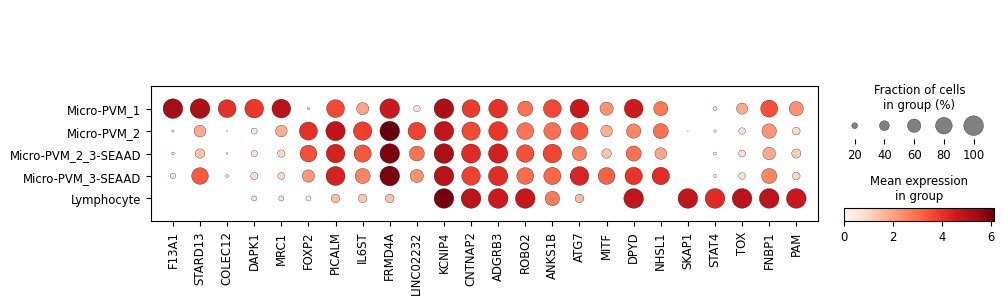

In [15]:
#Dot plot
sc.pl.dotplot(
    adata_markers,
    var_names=top_markers['names'].unique(),
    groupby='Supertype'
)

/tmp/ipykernel_6671/4170879487.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


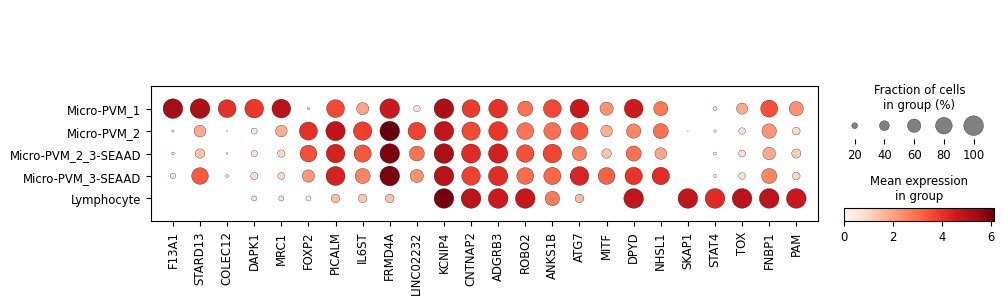

In [16]:
#Save your plot
sc.pl.dotplot(
    adata_markers,
    var_names=top_markers['names'].unique(),
    groupby='Supertype',
    save='_marker_dotplot.png'
)

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#paper 2

In [20]:
import pandas as pd
import glob

# find files
print(glob.glob('/content/**/*.csv.gz', recursive=True))

# load with the correct path after checking output
counts = pd.read_csv('/content/GSE138852_counts.csv.gz', index_col=0)
meta = pd.read_csv('/content/GSE138852_covariates.csv.gz')

print("Counts shape:", counts.shape)
print("Metadata shape:", meta.shape)

print("\nCounts preview:")
print(counts.iloc[:5, :5])

print("\nMetadata preview:")
print(meta.head())

['/content/GSE138852_counts.csv.gz', '/content/GSE138852_covariates.csv.gz']
Counts shape: (10850, 13214)
Metadata shape: (13214, 6)

Counts preview:
               AAACCTGGTAGAAAGG_AD5_AD6  AAACCTGGTAGCGATG_AD5_AD6  \
FO538757.2                            0                         0   
AP006222.2                            0                         0   
RP5-857K21.4                          0                         0   
RP11-206L10.9                         0                         0   
NOC2L                                 0                         0   

               AAACCTGTCAGTCAGT_AD5_AD6  AAACCTGTCCAAACAC_AD5_AD6  \
FO538757.2                            0                         0   
AP006222.2                            0                         0   
RP5-857K21.4                          0                         0   
RP11-206L10.9                         0                         0   
NOC2L                                 0                         0   

               AAACC

In [3]:
import pandas as pd

counts = pd.read_csv('/content/GSE138852_counts.csv.gz', index_col=0)
meta = pd.read_csv('/content/GSE138852_covariates.csv.gz')

print("Counts shape:", counts.shape)
print("Metadata shape:", meta.shape)
meta.head()

Counts shape: (10850, 13214)
Metadata shape: (13214, 6)


,Unnamed: 0,oupSample.batchCond,oupSample.cellType,oupSample.cellType_batchCond,oupSample.subclustID,oupSample.subclustCond
0,AAACCTGGTAGAAAGG_AD5_AD6,AD,oligo,oligo_AD,o3,AD
1,AAACCTGGTAGCGATG_AD5_AD6,AD,oligo,oligo_AD,o3,AD
2,AAACCTGTCAGTCAGT_AD5_AD6,AD,oligo,oligo_AD,o3,AD
3,AAACCTGTCCAAACAC_AD5_AD6,AD,oligo,oligo_AD,o3,AD
4,AAACCTGTCCAGTATG_AD5_AD6,AD,oligo,oligo_AD,o3,AD


In [4]:
# align counts and metadata
meta = meta.set_index('Unnamed: 0')
counts = counts.loc[:, meta.index]

print("Aligned counts shape:", counts.shape)
print("Aligned metadata shape:", meta.shape)
print("\nAD vs Control counts:")
print(meta['oupSample.batchCond'].value_counts())

Aligned counts shape: (10850, 13214)
Aligned metadata shape: (13214, 5)

AD vs Control counts:
oupSample.batchCond
AD    6673
ct    6541
Name: count, dtype: int64


In [5]:
# split AD vs Control
ad_cells = meta[meta['oupSample.batchCond'] == 'AD'].index
control_cells = meta[meta['oupSample.batchCond'] == 'Control'].index

print("AD cells:", len(ad_cells))
print("Control cells:", len(control_cells))

AD cells: 6673
Control cells: 0


In [6]:
# split AD vs control correctly
ad_cells = meta[meta['oupSample.batchCond'] == 'AD'].index
control_cells = meta[meta['oupSample.batchCond'] == 'ct'].index

print("AD cells:", len(ad_cells))
print("Control cells:", len(control_cells))

AD cells: 6673
Control cells: 6541


In [7]:
counts_ad = counts[ad_cells]
counts_control = counts[control_cells]

print("AD matrix shape:", counts_ad.shape)
print("Control matrix shape:", counts_control.shape)

AD matrix shape: (10850, 6673)
Control matrix shape: (10850, 6541)


In [8]:
mean_ad = counts_ad.mean(axis=1)
mean_control = counts_control.mean(axis=1)

deg_df = pd.DataFrame({
    'mean_AD': mean_ad,
    'mean_Control': mean_control
})

deg_df.head()

,mean_AD,mean_Control
FO538757.2,0.155702,0.113438
AP006222.2,0.023528,0.033328
RP5-857K21.4,0.107598,0.153340
RP11-206L10.9,0.030721,0.026449
NOC2L,0.036266,0.032258


In [9]:
#Compute log fold change
import numpy as np

deg_df['log2FC'] = np.log2((deg_df['mean_AD'] + 1) / (deg_df['mean_Control'] + 1))

deg_df.head()

,mean_AD,mean_Control,log2FC
FO538757.2,0.155702,0.113438,0.053748
AP006222.2,0.023528,0.033328,-0.013749
RP5-857K21.4,0.107598,0.153340,-0.058384
RP11-206L10.9,0.030721,0.026449,0.005992
NOC2L,0.036266,0.032258,0.005590


In [10]:
#Find top genes
# sort by highest difference
deg_df_sorted = deg_df.sort_values(by='log2FC', ascending=False)

# top upregulated genes in AD
top_genes = deg_df_sorted.head(20)

top_genes

,mean_AD,mean_Control,log2FC
LINGO1,3.797692,0.514447,1.663549
NEAT1,3.153604,0.944351,1.095075
LINC00486,12.549678,5.609081,1.035737
HSPA1A,1.444628,0.297661,0.913701
CRYAB,2.088116,0.885950,0.711436
SPP1,1.447175,0.514600,0.692180
ERBB2IP,1.682452,0.769454,0.600248
MT-ND4,1.137719,0.438006,0.572002
GFAP,0.887757,0.339398,0.495088
QDPR,1.217443,0.591653,0.478372


In [11]:
#Top downregulated genes
bottom_genes = deg_df.sort_values(by='log2FC').head(20)

bottom_genes

,mean_AD,mean_Control,log2FC
NRXN1,0.572306,3.655404,-1.566024
SLC1A2,0.341526,2.932426,-1.551545
LSAMP,1.284130,5.049228,-1.405106
DPP10,0.974224,4.130561,-1.377831
GPC5,0.330586,2.442440,-1.371370
CTNNA2,0.610970,3.110075,-1.351235
GPM6A,0.507418,2.832442,-1.346184
NTM,0.842200,2.857667,-1.066299
RORA,0.460513,2.044489,-1.059725
LRP1B,1.271842,3.565357,-1.006865


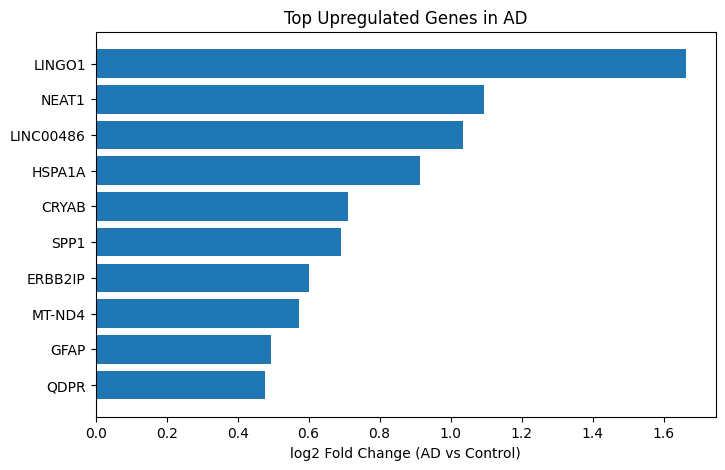

In [12]:
#visualization
import matplotlib.pyplot as plt

# plot top 10 genes
top10 = top_genes.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10.index, top10['log2FC'])
plt.xlabel("log2 Fold Change (AD vs Control)")
plt.title("Top Upregulated Genes in AD")
plt.gca().invert_yaxis()
plt.show()

In [14]:
#Compute p-values (t-test)
from scipy.stats import ttest_ind

p_values = []

for gene in counts.index:
    ad_vals = counts_ad.loc[gene]
    ctrl_vals = counts_control.loc[gene]

    stat, p = ttest_ind(ad_vals, ctrl_vals, equal_var=False)
    p_values.append(p)

deg_df['p_value'] = p_values

In [15]:
#Add -log10(p-value)
import numpy as np

deg_df['neg_log10_p'] = -np.log10(deg_df['p_value'] + 1e-10)

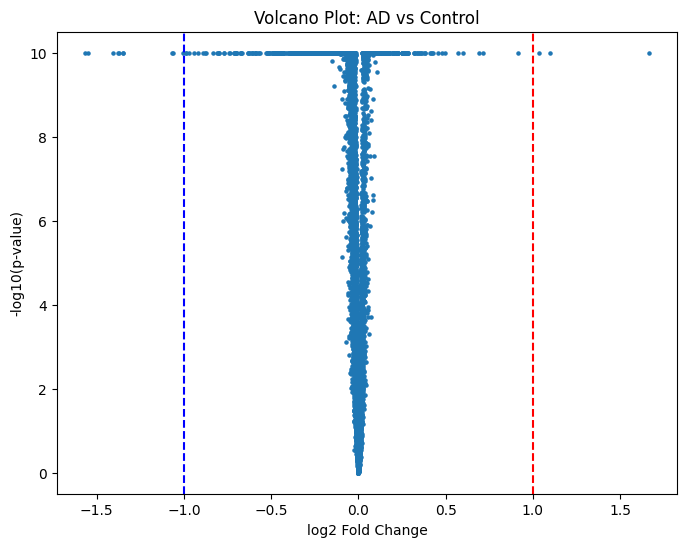

In [16]:
#Volcano Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(deg_df['log2FC'], deg_df['neg_log10_p'], s=5)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: AD vs Control")

plt.axvline(x=1, color='red', linestyle='--')
plt.axvline(x=-1, color='blue', linestyle='--')

plt.show()

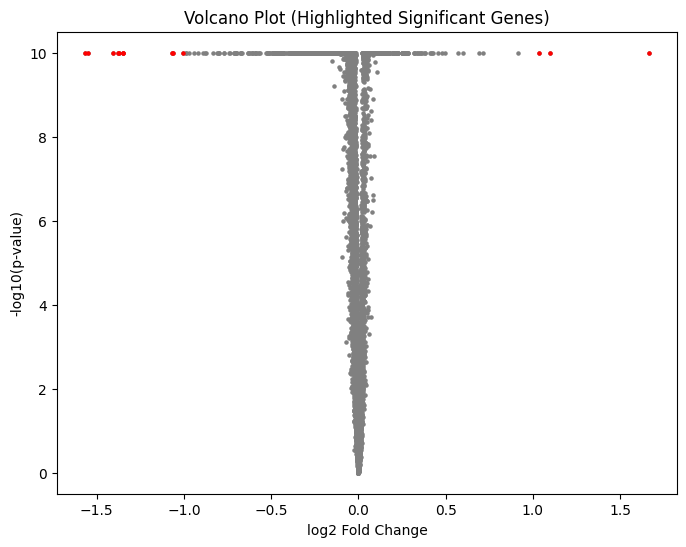

In [17]:
#highlight significant genes
significant = deg_df[(deg_df['p_value'] < 0.05) & (abs(deg_df['log2FC']) > 1)]

plt.figure(figsize=(8,6))

plt.scatter(deg_df['log2FC'], deg_df['neg_log10_p'], color='gray', s=5)
plt.scatter(significant['log2FC'], significant['neg_log10_p'], color='red', s=5)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Highlighted Significant Genes)")

plt.show()

In [18]:
#Heatmap
top_genes_list = deg_df.sort_values(by='log2FC', ascending=False).head(20).index

In [19]:
# combine AD + Control
combined_counts = counts.loc[top_genes_list]

# log transform (important)
combined_counts = np.log1p(combined_counts)

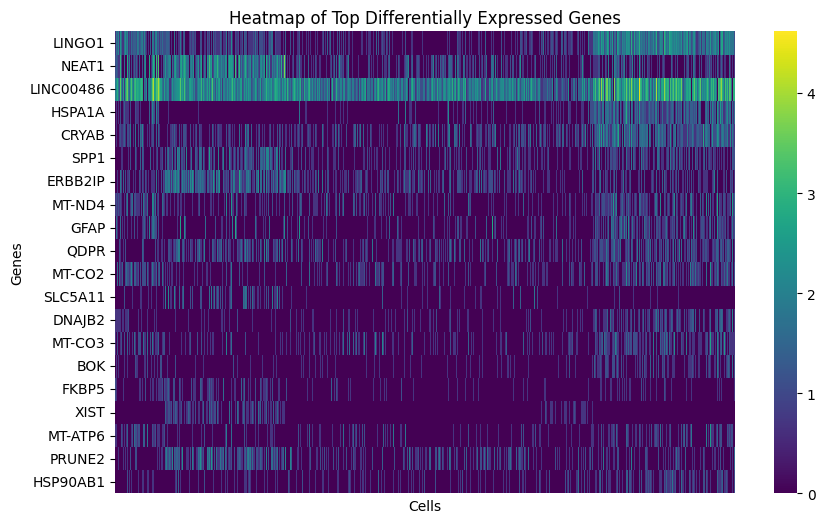

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(combined_counts, cmap='viridis', xticklabels=False)

plt.title("Heatmap of Top Differentially Expressed Genes")
plt.xlabel("Cells")
plt.ylabel("Genes")

plt.show()

In [21]:
deg_df.to_csv('/content/deg_results.csv')
top_genes.to_csv('/content/top_upregulated_genes.csv')
bottom_genes.to_csv('/content/top_downregulated_genes.csv')

In [23]:
# sort by significance
final_results = deg_df.sort_values(by='p_value')

final_results.head(20)

,mean_AD,mean_Control,log2FC,p_value,neg_log10_p
GPM6A,0.507418,2.832442,-1.346184,0.000000e+00,10.0
NTM,0.842200,2.857667,-1.066299,0.000000e+00,10.0
LSAMP,1.284130,5.049228,-1.405106,0.000000e+00,10.0
HSPA1A,1.444628,0.297661,0.913701,0.000000e+00,10.0
LINGO1,3.797692,0.514447,1.663549,0.000000e+00,10.0
LINC00486,12.549678,5.609081,1.035737,0.000000e+00,10.0
RORA,0.460513,2.044489,-1.059725,0.000000e+00,10.0
LRP1B,1.271842,3.565357,-1.006865,0.000000e+00,10.0
NRXN1,0.572306,3.655404,-1.566024,0.000000e+00,10.0
NPAS3,1.485988,3.693931,-0.916977,8.116124e-306,10.0


In [24]:
final_results.to_csv('/content/final_deg_results.csv')

In [25]:
#Get top DE genes
top_deg_genes = deg_df.sort_values(by='log2FC', ascending=False).head(50).index

In [27]:
import pandas as pd

markers = pd.read_csv('/content/drive/MyDrive/marker_genes.csv')

markers.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Micro-PVM_1,F13A1,7.020785,9.623757,2.206247e-12,8.075085e-08
1,Micro-PVM_1,STARD13,6.537881,4.978561,6.239660e-11,4.567556e-07
2,Micro-PVM_1,COLEC12,6.195859,9.514892,5.796804e-10,2.281651e-06
3,Micro-PVM_1,DAPK1,6.184401,5.751043,6.233848e-10,2.281651e-06
4,Micro-PVM_1,MRC1,6.139421,5.321693,8.282277e-10,2.472873e-06


In [28]:
# get marker genes
marker_gene_list = markers['names'].unique()

# find overlap
overlap_genes = set(top_deg_genes).intersection(set(marker_gene_list))

print("Number of overlapping genes:", len(overlap_genes))
print("Overlapping genes:", list(overlap_genes)[:20])

Number of overlapping genes: 49
Overlapping genes: ['MT-CYB', 'CDH19', 'SGK1', 'PSAP', 'GPRC5B', 'MT-CO3', 'MT-ND4', 'QDPR', 'XIST', 'LAMP2', 'CLK1', 'SPP1', 'ABCA2', 'SLC5A11', 'TMTC4', 'CLDN11', 'MT-ATP6', 'HSPA1A', 'TMEM165', 'NDRG1']


In [29]:
#which cell types these genes belong to
overlap_df = markers[markers['names'].isin(overlap_genes)]
overlap_df.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
46,Micro-PVM_1,FKBP5,3.870449,1.024675,0.000109,0.030122
187,Micro-PVM_1,MT-ND2,2.190044,1.617518,0.028521,1.000000
204,Micro-PVM_1,NEAT1,2.129362,0.487396,0.033224,1.000000
340,Micro-PVM_1,MT-CO3,1.641790,0.955558,0.100633,1.000000
425,Micro-PVM_1,SPOCK1,1.455503,1.277437,0.145530,1.000000
576,Micro-PVM_1,TMEM144,1.210656,1.126151,0.226027,1.000000
749,Micro-PVM_1,MT-ND4,1.061286,0.626144,0.288560,1.000000
1252,Micro-PVM_1,LINC00486,0.746847,1.155358,0.455156,1.000000
1357,Micro-PVM_1,QDPR,0.702291,1.125021,0.482498,1.000000
1420,Micro-PVM_1,HSP90AA1,0.679376,0.378013,0.496900,1.000000
